In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


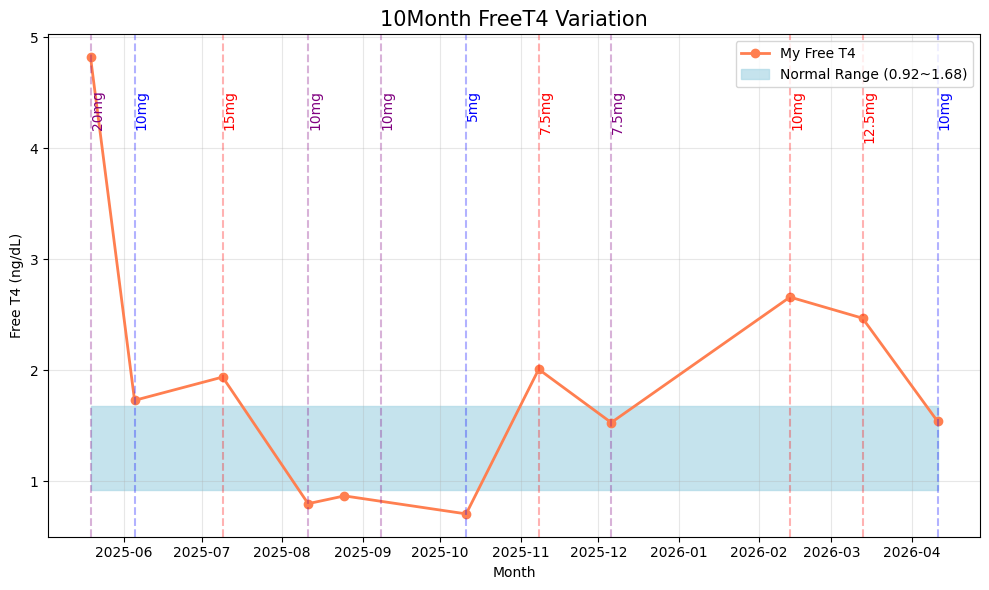

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/github/FreeT4_data.csv')

# 날짜 데이터를 컴퓨터가 인식할 수 있는 '진짜 날짜' 형식으로 변환.
df['날짜'] = pd.to_datetime(df['날짜'])

# 2. 그래프 그리기
plt.figure(figsize=(10, 6))

# 3. 데이터 선 그리기
plt.plot(df['날짜'], df['수치값'], marker='o', linestyle='-', color='coral', linewidth = 2, label='My Free T4')

# 4. 정상 범위 표시하기
min_ref = 0.92
max_ref = 1.68
plt.fill_between(df['날짜'], 0.92, 1.68, color='lightblue', alpha=0.7, label='Normal Range (0.92~1.68)')

# 5. 복용량 변경 시점 표시
dose_changes = [
    {'date': '2025-05-19', 'label': '20mg', 'color': 'purple'},
    {'date': '2025-06-05', 'label': '10mg', 'color': 'blue'},
    {'date': '2025-07-09', 'label': '15mg', 'color': 'red'},
    {'date': '2025-08-11', 'label': '10mg', 'color': 'purple'},
    {'date': '2025-09-08', 'label': '10mg', 'color': 'purple'},
    {'date': '2025-10-11', 'label': '5mg', 'color': 'blue'},
    {'date': '2025-11-08', 'label': '7.5mg', 'color': 'red'},
    {'date': '2025-12-06', 'label': '7.5mg', 'color': 'purple'},
    {'date': '2026-02-13', 'label': '10mg', 'color': 'red'},
    {'date': '2026-03-13', 'label': '12.5mg', 'color': 'red'},
    {'date': '2026-04-11', 'label': '10mg', 'color': 'blue'}
]

for change in dose_changes:
    change_date = pd.to_datetime(change['date'])
    plt.axvline(x=change_date, color=change['color'], linestyle='--', alpha=0.3)
    plt.text(change_date, plt.ylim()[1]*0.9, change['label'],
             rotation=90, verticalalignment='top', fontsize=10, color=change['color'])

# 6. 그래프 시각화
plt.title('10Month FreeT4 Variation', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Free T4 (ng/dL)')
plt.legend() # 범례 표시
plt.grid(True, alpha=0.3) # 격자 무늬

# 7. 결과 확인
plt.tight_layout()
plt.savefig('free_t4_analysis.png') # 깃허브용 사진 저장
plt.show()